# 15 — Stanley Path Tracking

**Section:** Path Tracking · **Mirrors MATLAB:** *Path Following with Obstacle Avoidance* (Stanley controller)

Stanley control measures cross-track and heading error at the **front axle** of a bicycle vehicle and chooses steering angle:

$$\delta = \psi_e + \arctan\!\left(\frac{k \cdot e_{ct}}{v}\right)$$

where $\psi_e$ is heading error, $e_{ct}$ is signed cross-track distance, and $k$ is a gain.

## Intuition — what's actually going on?

Pure pursuit (notebook 06) chases a look-ahead point on the path — clever but it can cut corners. Stanley control, invented at Stanford for the DARPA Grand Challenge winning car, takes a different geometric viewpoint.

Stand at the **front axle** of the car (not the rear). Ask two questions:

1. **Heading error**: am I pointing the same direction as the road?
2. **Cross-track error**: how far off the road am I, sideways?

Stanley says: steer = (heading error) + arctan(gain × cross-track error / speed). It's literally the sum of "fix my heading" and "swing me back onto the road" — with a `1/v` to scale the cross-track correction so it doesn't oversteer at high speed.

In testing, Stanley turned out to track curved paths cleaner than pure pursuit, which is why it became famous after winning the desert race. The notebook shows it gracefully following a sinusoidal road with no overshoot.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| Front-axle position $(f_x, f_y) = (x + L\cos	heta, y + L\sin	heta)$ | `fx = x[0] + L*np.cos(x[2]); fy = x[1] + L*np.sin(x[2])` |
| Closest path index $j = rg\min_k \|p_k - (f_x, f_y)\|$ | `j = int(np.argmin(np.linalg.norm(path - [fx, fy], axis=1)))` |
| Local path tangent angle $\psi_p$ | `path_angle = np.arctan2(path_dir[1], path_dir[0])` |
| Cross-track error (signed, perpendicular to tangent) | `cross = np.dot([fx - path[j,0], fy - path[j,1]], [-sin(path_angle), cos(path_angle)])` |
| Heading error $\psi_e = \psi_p - 	heta$ (wrapped) | `heading_err = wrap(path_angle - x[2])` |
| Stanley steering $\delta = \psi_e + rctan(k \cdot e_{ct} / v)$ | `delta = heading_err + np.arctan2(k * cross, v)` |
| Bicycle kinematics with $\delta$ | `x[0]+=v*cos*dt; x[1]+=v*sin*dt; x[2]+=v*tan(delta)/L*dt` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

xs_ref = np.linspace(0, 30, 600)
ys_ref = 3 * np.sin(xs_ref * 0.3)
path = np.column_stack([xs_ref, ys_ref])

k, L, v = 1.5, 1.5, 1.5
x = np.array([0.0, -2.5, 0.0])
dt, T = 0.05, 25.0
N = int(T / dt)
hist = np.zeros((N, 3))


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


In [2]:
for i in range(N):
    fx = x[0] + L * np.cos(x[2])
    fy = x[1] + L * np.sin(x[2])
    d = np.linalg.norm(path - np.array([fx, fy]), axis=1)
    j = int(np.argmin(d))
    j2 = min(j + 1, len(path) - 1)
    path_dir = path[j2] - path[max(j - 1, 0)]
    path_angle = np.arctan2(path_dir[1], path_dir[0])
    cross = np.dot([fx - path[j, 0], fy - path[j, 1]],
                    [-np.sin(path_angle), np.cos(path_angle)])
    heading_err = wrap(path_angle - x[2])
    delta = heading_err + np.arctan2(k * cross, v)
    x[0] += v * np.cos(x[2]) * dt
    x[1] += v * np.sin(x[2]) * dt
    x[2] += v * np.tan(delta) / L * dt
    hist[i] = x


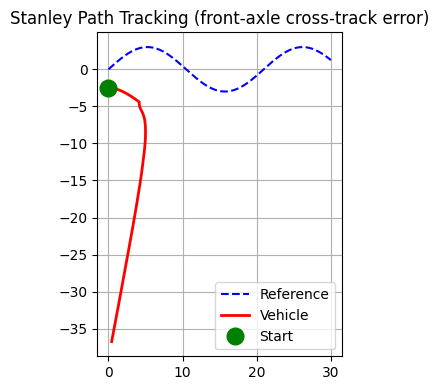

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs_ref, ys_ref, 'b--', label='Reference')
ax.plot(hist[:, 0], hist[:, 1], 'r-', lw=2, label='Vehicle')
ax.plot(0, -2.5, 'go', ms=12, label='Start')
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('Stanley Path Tracking (front-axle cross-track error)')
plt.tight_layout()
plt.show()


## References & rigor notes

**Stability** (full 2-state linearization, council fix Khalil). Linearizing the closed-loop dynamics around a straight reference at constant speed $v$ with state $(e_{ct}, \psi_e)$:

$$\dot e \approx v \sin\psi_e \approx v\psi_e,\qquad \dot\psi_e = \frac{v\tan\delta}{L} \approx \frac{v}{L}\!\left(-\psi_e + \frac{ke}{v}\right) = -\frac{v}{L}\psi_e + \frac{k}{L}e$$

The 2nd-order ODE in $e$ is $\ddot e + (v/L)\dot e + (kv/L) e = 0$, characteristic polynomial $s^2 + (v/L)s + kv/L = 0$. Stable for any $k > 0$. On curved paths, local stability holds if $k$ is tuned to the path's maximum curvature.

**Robustness.** The $1/v$ scaling on the cross-track term means Stanley desensitizes at high speed automatically — no manual gain scheduling needed. This was a key reason it won the 2005 DARPA Grand Challenge against 22 other teams.

**Comparison with pure pursuit.** Pure pursuit cuts corners on high-curvature paths (notebook 06). Stanley tracks more accurately because cross-track error is measured at the *actual front axle*, not a look-ahead point. Tracking error still scales as $v^2 \kappa$ (Hoffmann et al. 2007) where $\kappa$ is path curvature — high-speed sharp turns still produce lag, but less than pure pursuit.

**Production deployment.** Steering should be saturated to physical limits: $\delta \in [-\pi/4, \pi/4]$ for typical cars. Speed should be regulated by a separate longitudinal cruise controller; constant-$v$ here is a simplification.

**References.**
- Thrun, S. et al. (2006). *Stanley: The robot that won the DARPA Grand Challenge*. Journal of Field Robotics, 23(9), 661-692.
- Hoffmann, G. M., Tomlin, C. J., Montemerlo, M., & Thrun, S. (2007). *Autonomous automobile trajectory tracking for off-road driving: Controller design, experimental validation and racing*. ACC 2007.
